In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models

In [ ]:
(dataset_train, dataset_test), info = tfds.load(
      "cats_vs_dogs",
     split=["train[:80%]", "train[80%:]"],
     as_supervised=True, #cat 0, #dog 1
     with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.IVTOC9_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image,(150,150))
    image = image / 255.0
    return image, label

In [ ]:
train_dataset = dataset_train.map(preprocess).batch(32)
test_dataset = dataset_test.map(preprocess).batch(32)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compile model
model.compile(
     optimizer='adam',
     loss='binary_crossentropy',
     metrics=['accuracy']
)

Epoch 1/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 859s 1s/step - accuracy: 0.7861 - loss: 0.4520
Epoch 2/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 855s 1s/step - accuracy: 0.8368 - loss: 0.3637
Epoch 3/3
582/582 ━━━━━━━━━━━━━━━━━━━━ 862s 1s/step - accuracy: 0.8881 - loss: 0.2620
146/146 ━━━━━━━━━━━━━━━━━━━━ 69s 471ms/step - accuracy: 0.7887 - loss: 0.5347
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
Predicted: Dog 🐶


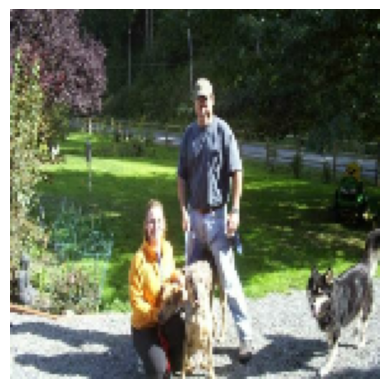

In [ ]:
model.fit(train_dataset, epochs=3)

# Evaluate
model.evaluate(test_dataset)

# Show prediction with image
for image, label in test_dataset.take(1):

    prediction = model.predict(image)

    plt.imshow(image[2])
    plt.axis("off")

    if prediction[5] > 0.5:
        print("Predicted: Dog 🐶")
    else:
        print("Predicted: Cat 🐱")
    plt.show()